### Carregando os dados

In [36]:
import pandas as pd
import numpy as np

Sw_matrix = pd.read_csv("Sw_matrix.csv", header=None).values  # ou sem .values se quiser manter como DataFrame
Sg_matrix = pd.read_csv("Sg_matrix.csv", header=None).values

p_exp_matrix = pd.read_csv("delta_p_exp.csv")
p_run_64_matrix = pd.read_csv("run_187_p.csv")
Sb_run_64_matrix = pd.read_csv("run_187_Sb.csv")

print("Shape Sw:", Sw_matrix.shape)   # (n_timesteps, n_pontos_espaciais)
print("Shape Sg:", Sg_matrix.shape)

Shape Sw: (151, 100)
Shape Sg: (151, 100)


In [37]:
Sb_run_64_matrix = Sb_run_64_matrix.drop(["x/t"], axis = 1)
Sb_run_64_matrix = Sb_run_64_matrix.drop("0", axis = 1)

In [38]:
Sw = pd.DataFrame(data = Sw_matrix)
Sg = pd.DataFrame(data = Sg_matrix)

In [39]:
Sw = Sw.dropna(axis = 1)
Sg = Sg.dropna(axis = 1)

### Plotando os perfis de saturação

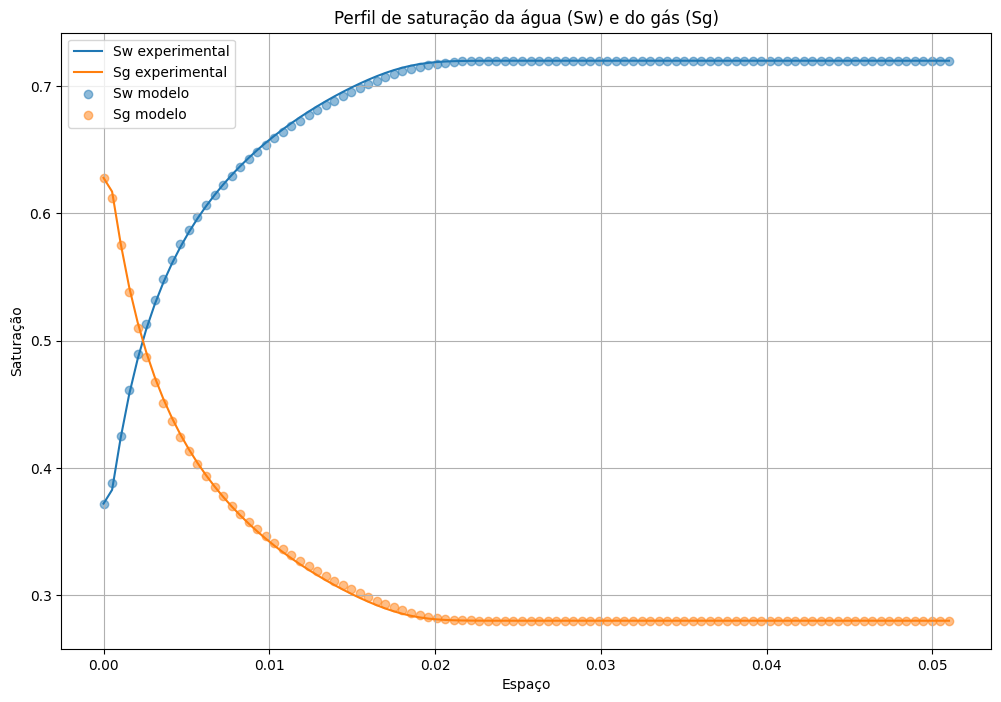

In [50]:
import matplotlib.pyplot as plt
plt.figure(figsize = (12,8))

t = np.linspace(0, 150, 150)
x = np.linspace(0, 0.051, 100)

#Perfil de saturação do ultimo tempo
plt.plot(x,Sw.iloc[-1,:].values, label = "Sw experimental")
plt.plot(x,Sg.iloc[-1,:].values, label = "Sg experimental")
plt.scatter(x, Sb_run_64_matrix.iloc[:, -1], label = "Sw modelo", alpha = 0.5)
plt.scatter(x,1 - (Sb_run_64_matrix.iloc[:, -1]), label = "Sg modelo", alpha = 0.5)
plt.grid()
plt.title("Perfil de saturação da água (Sw) e do gás (Sg)")
plt.xlabel("Espaço")
plt.ylabel("Saturação")
plt.legend()
plt.show()

### Removendo as colunas do espaço e tempos iniciais onde a pressão não foi calculada (igual a 0)

In [41]:
p_run_64_matrix = p_run_64_matrix.drop(["x/t"], axis = 1)
p_run_64_matrix = p_run_64_matrix.drop("0", axis = 1)
p_run_64_matrix = p_run_64_matrix.iloc[1 , :] - p_run_64_matrix.iloc[-1 , :]

### Comparando os resultados do modelo com os dados sintéticos

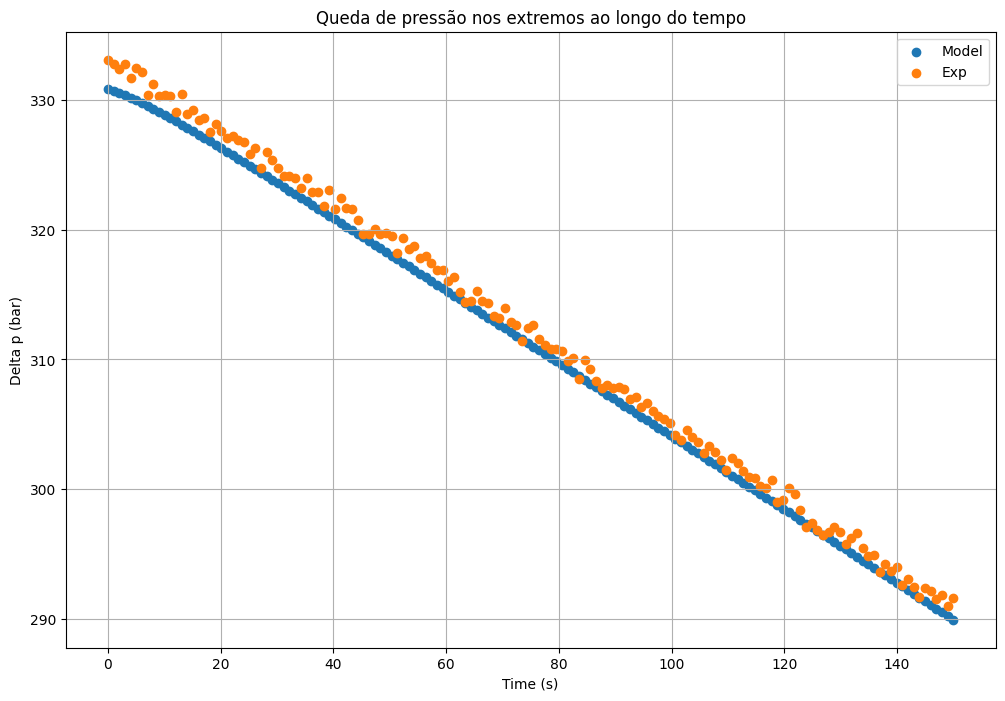

In [42]:
plt.figure(figsize = (12, 8))
plt.title("Queda de pressão nos extremos ao longo do tempo")
t1 = np.linspace(0, 150, 150)
t2 = np.linspace(0, 150, 150)
plt.scatter(t1, p_run_64_matrix.values , label = "Model")
plt.scatter(t1, p_exp_matrix.iloc[:, 1], label = "Exp")
plt.xlabel("Time (s)")
plt.ylabel("Delta p (bar)")
plt.legend()
plt.grid()
plt.show()